# Macrobot: automated powdery mildew quantification on a test plate (minRGB pipeline)

**Paper:** Lück S., Strickert M., Lorbeer M., Melchert F., Backhaus A., Kilias D., Seiffert U., Schweizer P., Djamei A., Douchkov D. *"Macrobot" – an automated segmentation-based system for powdery mildew disease quantification*, bioRxiv 2020.03.16.993451v1 (posted 2020-03-18), DOI: [10.1101/2020.03.16.993451](https://doi.org/10.1101/2020.03.16.993451)

**Author code used:** `snowformatics/macrobot` @ commit `bb72fc5bfa31afd3fd8c17d5016ae9f79059a88b` (GPL-3.0), the authors' maintained implementation (later published as Lueck et al. 2020, JOSS 5(51):2259, "BluVision Macro"). The repository cited by the preprint itself (`macrobot_paper`) is no longer available (HTTP 404), so this notebook pins the maintained head revision; the minRGB mildew pipeline matches the paper's §3.1/§3.3 description.

**Scope — PARTIAL DEMONSTRATION (1 plate).** This notebook reproduces the paper's rule-based minRGB disease-scoring path on the authors' own single test plate (e!DAL DOI 10.5447/ipk/2020/7, plate `20190709_102939_exp40_P02-3`, barley powdery mildew, 6 days after inoculation): frame/leaf segmentation → minRGB feature → rule-based prediction → per-leaf infection percentage CSV. It does **not** reproduce the machine-learning branch (§3.2), the 108-plate validation experiment, or dataset-level correlations.

**Execution status:** executed in Google Colab (CPU runtime) — see the outputs and the validation record at the end.

**Note on authorship:** the scientific pipeline cells call the authors' own package code (cloned at the pinned commit) unchanged; only glue cells (downloads, display, comparison) are notebook-specific. *AI-assisted glue code; the authors did not provide this Colab notebook. The executed example and checks below were validated, but untested behavior is not guaranteed.*

**Japanese summary (日本語要約):**
このノートブックは、Macrobot（Powdery mildew 自動定量化、bioRxiv 2020.03.16.993451）のうち、ルールベースの **minRGB 病変スコアリング経路** を、著者自身のテスト画像プレート1枚で再現します。著者の公開リポジトリ（ピン留したコミット）をそのまま利用し、フレーム/葉のセグメンテーション → minRGB特徴量 → ルールベース予測 → 葉ごとの感染率CSV生成までを実行します。機械学習分岐や大規模検証実験（n=108）は対象外です。GPUは不要で、CPUランタイムで動作します。

## 1. Runtime selection & how to run

**Select Runtime → Change runtime type → CPU** (the default free CPU runtime is sufficient and recommended; `None` hardware accelerator).

- No GPU is used anywhere in this reproduction: the paper's minRGB branch is rule-based OpenCV/NumPy image processing with no trained model or weights.
- Expected total time on a fresh CPU runtime: roughly 5–15 minutes, dominated by the ~tens-of-MB test-image download from e!DAL and the pure-Python per-pixel prediction loop of the author code.
- Use **Runtime → Run all**. All downloads happen inside this notebook on the Colab VM; nothing is read from your Drive or any local machine.

**日本語:** ランタイムは **CPU（アクセラレータなし）** を選択してください。この再現にGPUは不要です（学習済みモデルを使わないルールベース処理のため）。**ランタイム → すべてのセルを実行** で動作します。所要時間の目安は5〜15分です。

### 1.1 Environment check

Verify the scientific dependencies the author package needs (`numpy`, `opencv-python`, `scikit-image`, `jinja2`); anything missing is installed here so the notebook is self-contained, otherwise the preinstalled stack is used and its versions recorded. One author-code incompatibility with **any** modern OpenCV is repaired in §3 with a documented behavior-preserving shim (see there): the author's `segmentation.py` calls `contours.reverse()` on the `cv2.findContours` result, and modern OpenCV (4.x and 5.x alike on current Python) returns an immutable tuple, while the author's pinned `opencv 4.2.0.34` has no wheels for current Colab Python.

**日本語:** 著者パッケージの依存関係（numpy / OpenCV / scikit-image / jinja2）を確認・記録します。現行のOpenCVでは `cv2.findContours` がイミュータブルな tuple を返すため、著者コードの `contours.reverse()` が失敗します。これに対する最小限の互換シムは §3 で説明・適用します。

In [ ]:
import importlib.metadata as importlib_metadata
import importlib.util
import subprocess
import sys

for dist in ("opencv-python", "opencv-contrib-python", "opencv-python-headless"):
    try:
        print(f"preinstalled {dist}: {importlib_metadata.version(dist)}")
    except importlib_metadata.PackageNotFoundError:
        pass

REQUIRED = {"numpy": "numpy", "cv2": "opencv-python-headless", "skimage": "scikit-image", "jinja2": "jinja2"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)

import cv2
import jinja2
import numpy as np
import skimage

print("numpy       ", np.__version__)
print("opencv      ", cv2.__version__)
print("scikit-image", skimage.__version__)
print("jinja2      ", jinja2.__version__)
print("python      ", sys.version.split()[0])

preinstalled opencv-python: 5.0.0.93
preinstalled opencv-contrib-python: 4.14.0.94
preinstalled opencv-python-headless: 5.0.0.93
numpy        2.1.3
opencv       5.0.0
scikit-image 0.25.2
jinja2       3.1.6
python       3.13.16


### 1.2 Get the pinned author code (inside Colab only)

Partial-clone the author repository at the exact verified commit `bb72fc5bfa31afd3fd8c17d5016ae9f79059a88b` with a blobless clone and a sparse checkout of the `macrobot/` package directory only (this includes the `settings_ipk.ini` configuration and the HTML report template the pipeline reads at runtime). Any previous copy is removed first so every run starts from a fresh clone; the checked-out commit is asserted to match the pin. Per the paper's license (GPL-3.0), the author code stays intact; we import it instead of re-implementing it.

**日本語:** 著者リポジトリを検証済みコミットに部分クローンし（`macrobot/` パッケージのみ、実行のたびに再クローン）、コミット一致を確認してからインポートします。科学的中核は著者コードをそのまま使います。

In [ ]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/snowformatics/macrobot"
PINNED_COMMIT = "bb72fc5bfa31afd3fd8c17d5016ae9f79059a88b"
REPO_DIR = "/content/macrobot"

shutil.rmtree(REPO_DIR, ignore_errors=True)  # always start from a fresh clone
subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO_DIR], check=True)
subprocess.run(["git", "-C", REPO_DIR, "sparse-checkout", "set", "macrobot"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "checkout", "--detach", PINNED_COMMIT], check=True)

head = subprocess.run(["git", "-C", REPO_DIR, "rev-parse", "HEAD"],
                      capture_output=True, text=True, check=True).stdout.strip()
assert head == PINNED_COMMIT, f"checked-out commit {head} != pinned {PINNED_COMMIT}"
print("macrobot checked out at pinned commit:", head)

sys.path.insert(0, REPO_DIR)
import macrobot  # noqa: E402

print("importing macrobot from:", macrobot.__file__)

macrobot checked out at pinned commit: bb72fc5bfa31afd3fd8c17d5016ae9f79059a88b
importing macrobot from: /content/macrobot/macrobot/__init__.py


### 1.3 Download the authors' test plate (e!DAL DOI 10.5447/ipk/2020/7)

The authors wired a built-in test case into their software: `orga.download_test_images` fetches the plate `20190709_102939_exp40_P02-3` (barley powdery mildew, 6 days after inoculation, IPK Macrobot hardware: 16-bit single-channel TIFFs per LED channel) as a ZIP from the e!DAL repository and extracts it. We call the author's own function unchanged, after removing any previous copy so the bytes are re-downloaded fresh on every run; the extraction is then validated: exactly 6 files, each starting with a real TIFF signature (`II*\0` / `MM\0`), non-empty.

**日本語:** 著者ソフトに組み込まれたテスト画像ダウンロード関数をそのまま呼び出し、e!DALからテストプレート（16bit TIFF×6ファイル）を毎回新規に取得します。抽出後にファイル数とTIFFシグネチャを検証します。

In [ ]:
import os
import shutil

from macrobot.orga import download_test_images

DATA_PATH = "/content/data"
shutil.rmtree(os.path.join(DATA_PATH, "gb2_exp40"), ignore_errors=True)  # force a fresh download
download_test_images(DATA_PATH)

PLATE_DIR = os.path.join(DATA_PATH, "gb2_exp40", "6dai", "20190709_102939_exp40_P02-3")
plate_files = sorted(os.listdir(PLATE_DIR))
print(f"{len(plate_files)} files in {PLATE_DIR}:")
for fname in plate_files:
    fpath = os.path.join(PLATE_DIR, fname)
    with open(fpath, "rb") as fh:
        magic = fh.read(4)
    size = os.path.getsize(fpath)
    is_tif = magic[:2] in (b"II", b"MM")
    print(f"  {fname:55s} {size:>12,d} bytes  TIFF-signature={is_tif}")

assert len(plate_files) == 6, f"expected 6 extracted files, found {len(plate_files)}"
assert all(open(os.path.join(PLATE_DIR, f), "rb").read(2) in (b"II", b"MM") for f in plate_files), \
    "not all files are valid TIFFs"
print("test plate download verified.")

/content/data
=== Downloading test images ===


6 files in /content/data/gb2_exp40/6dai/20190709_102939_exp40_P02-3:
  20190709_102939_exp40_P02-3_000_backlight.tif              9,288,462 bytes  TIFF-signature=True
  20190709_102939_exp40_P02-3_001_blue.tif                  14,431,140 bytes  TIFF-signature=True
  20190709_102939_exp40_P02-3_002_green.tif                 13,390,836 bytes  TIFF-signature=True
  20190709_102939_exp40_P02-3_003_red.tif                   13,676,456 bytes  TIFF-signature=True
  20190709_102939_exp40_P02-3_004_uvs.tif                   12,036,192 bytes  TIFF-signature=True
  20190709_102939_exp40_P02-3_preview.tif                   11,942,434 bytes  TIFF-signature=True
test plate download verified.


## 2. Input preview (actual sample, before any analysis)

The Macrobot hardware captures each plate once per narrowband LED (365/470/530/625 nm) with a 14-bit monochrome camera; the paper's §2.2/§3.1 and `MacrobotPipeline.merge_channels` assemble the analysis RGB by stacking the blue-, green- and red-LED channel images (in that order) into one 3-channel image, then applying a percentile white balance (`helpers.whitebalance`, factor from `settings_ipk.ini`). Below we display the raw channel stack (before white balance, exactly the bytes the pipeline will read) plus the backlight and UV channels. This is the real downloaded sample, not a figure from the paper.

**日本語:** 各LED波長で撮影された16bitモノクロ画像を、著者コードと同じ方法（青・緑・赤LEDの順にスタック）で合成し、解析前の実サンプルを表示します（ホワイトバランス前の生画像）。バックライトとUVチャンネルも併せて示します。

backlight: (2472, 3296) uint16 | red: (2472, 3296) | blue: (2472, 3296) | green: (2472, 3296) | uvs: (2472, 3296)


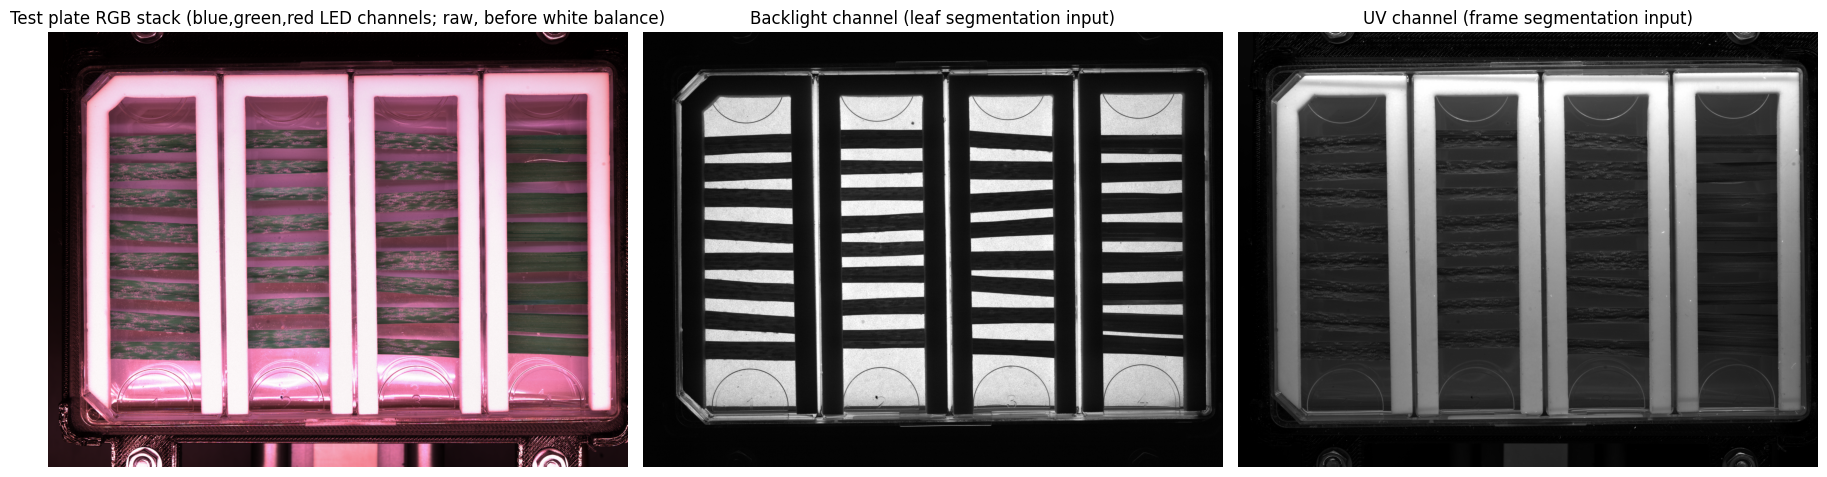

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def load_gray(name):
    for fname in plate_files:
        if fname.endswith(name):
            return cv2.imread(os.path.join(PLATE_DIR, fname), cv2.IMREAD_UNCHANGED)
    raise FileNotFoundError(name)


img_backlight = load_gray("backlight.tif")
img_red = load_gray("_red.tif")
img_blue = load_gray("_blue.tif")
img_green = load_gray("_green.tif")
img_uvs = load_gray("uvs.tif") if any(f.endswith("uvs.tif") for f in plate_files) else load_gray("uv.tif")

print("backlight:", img_backlight.shape, img_backlight.dtype, "| red:", img_red.shape,
      "| blue:", img_blue.shape, "| green:", img_green.shape, "| uvs:", img_uvs.shape)
assert img_backlight.shape == img_red.shape == img_blue.shape == img_green.shape == img_uvs.shape

# Author's channel order (macrobot/mb_pipeline.py merge_channels): stack blue, green, red LED images
image_rgb_raw = np.dstack((img_blue, img_green, img_red))


def stretch16(img):
    lo, hi = np.percentile(img, (1, 99))
    return np.clip((img.astype(np.float32) - lo) / max(hi - lo, 1e-6), 0, 1)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(stretch16(image_rgb_raw))
axes[0].set_title("Test plate RGB stack (blue,green,red LED channels; raw, before white balance)")
axes[1].imshow(stretch16(img_backlight), cmap="gray")
axes[1].set_title("Backlight channel (leaf segmentation input)")
axes[2].imshow(stretch16(img_uvs), cmap="gray")
axes[2].set_title("UV channel (frame segmentation input)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Run the author's minRGB mildew pipeline on the test plate

We run the authors' `BgtSegmenter` (the mildew segmenter used for the paper's powdery-mildew experiments) exactly as their CLI does (`mb -s test_images -d <out> -p mildew`), with three documented choices:

1. **`setting_file=settings_ipk.ini`** — the test plate is IPK-hardware data (downloaded from doi.ipk-gatersleben.de), and the current CLI maps hardware `ipk` to this settings file (segmentation thresholds, white-balance percentile, resize scale).
2. **`store_leaf_path=None`** — the CLI's `ipk` branch hardcodes a Windows network share (`//psg-09/...`) for optional per-leaf image export, which cannot exist on Colab; passing `None` keeps the scientific path identical while skipping only that optional file dump.
3. **`cv2.findContours` list shim** — the author code (`segmentation.py`, `segment_leaf_binary`, line ~304) calls `contours.reverse()` on the `findContours` result. Modern OpenCV (all 4.x/5.x lines available for current Python) returns contours as an immutable tuple, and the author's pinned OpenCV 4.2.0.34 has no wheels for this Python — this was verified by execution on Colab. The shim converts the contour sequence to a plain `list`, restoring the author's exact processing (reverse-order contours) without altering any numerical operation. The shim is applied at most once per kernel (idempotent) so "Run all" can be used repeatedly.
4. **CSV flush** — the author's CLI relies on interpreter exit to flush the results CSV file handle; in a notebook the file must be flushed explicitly after `start_pipeline()` before it is read, otherwise buffered rows never reach disk (observed as an empty CSV on the first validation attempt).

The pipeline (`MacrobotPipeline.start_pipeline`): read/resize the 5 channel TIFFs → RGB stack + white balance → Otsu frame segmentation on the UV image → lane extraction → minRGB feature per lane (`helpers.rgb_features(..., "minimum")`) → rule-based prediction per pixel (`prediction.predict_min_rgb`: minRGB green channel and backlight thresholds) → leaf segmentation and convex hulls on the backlight binary → per-leaf infection percentage `100 − infected_leaf_pixels / leaf_pixels × 100` written to a `;`-separated CSV.

**日本語:** 著者の `BgtSegmenter`（mildew 用セグメンタ）を、CLIと同じ構成で実行します（設定ファイルは `settings_ipk.ini`、葉画像の任意保存のみ `None`）。加えて、現行OpenCVで `findContours` が tuple を返すことによる `contours.reverse()` の失敗を避けるため、**挙動を変えない最小限のシム**（結果を list 化するだけ、複数回実行しても1回のみ適用）を適用し、実行後にCSVを明示的に flush します。UV画像からのフレーム検出、レーン抽出、minRGB特徴量、ルールベース予測、葉ごとの感染率CSV出力までを実行します。

In [ ]:
import time

import cv2

# Compatibility shim (behavior-preserving, AI-added glue):
# macrobot/segmentation.py:304 calls contours.reverse() on the cv2.findContours
# result; modern OpenCV returns an immutable tuple (verified by execution: 5.0.0
# and 4.14.0 both fail). The author pins opencv 4.2.0.34, which has no wheels for
# this Python. Converting the contour sequence to a list restores the author's
# exact processing without changing any numerical operation. Idempotent: the
# pristine binding is remembered on the cv2 module so repeated "Run all" in one
# kernel never double-wraps.
if getattr(cv2, "_mb_pristine_findContours", None) is not None:
    cv2.findContours = cv2._mb_pristine_findContours  # undo a previous run's shim

_orig_findContours = cv2.findContours
cv2._mb_pristine_findContours = _orig_findContours


def _findContours_as_list(*args, **kwargs):
    contours, hierarchy = _orig_findContours(*args, **kwargs)
    return list(contours), hierarchy


cv2.findContours = _findContours_as_list

from macrobot.bgt import BgtSegmenter

DESTINATION_PATH = "/content/mb_results"
EXPERIMENT, DAI = "gb2_exp40", "6dai"
SETTING_FILE = os.path.join(REPO_DIR, "macrobot", "settings_ipk.ini")

shutil.rmtree(DESTINATION_PATH, ignore_errors=True)  # remove any previous run's outputs
os.makedirs(os.path.join(DESTINATION_PATH, EXPERIMENT, DAI), exist_ok=True)
file_results = open(os.path.join(DESTINATION_PATH, EXPERIMENT, DAI, f"{EXPERIMENT}_leaf.csv"), "w")
file_results.write("index;expNr;dai;Plate_ID;Lane_ID;Leaf_ID;%_Inf\n")

images = sorted(f for f in plate_files if f.endswith((".tif", ".tiff")))
processor = BgtSegmenter(images, PLATE_DIR, DESTINATION_PATH, None,
                         EXPERIMENT, DAI, file_results, SETTING_FILE)

t0 = time.time()
plate_id, n_lanes, final_image_list, csv_name = processor.start_pipeline()
file_results.flush()  # author CLI relies on process exit to flush; a notebook must flush explicitly
elapsed = time.time() - t0
print(f"plate_id        : {plate_id}")
print(f"lanes segmented : {n_lanes}")
print(f"results CSV     : {csv_name}")
print(f"pipeline time   : {elapsed:.1f} s")

...Analyzing plate 20190709_102939_exp40_P02-3


plate_id        : 20190709_102939_exp40_P02-3
lanes segmented : 4
results CSV     : /content/mb_results/gb2_exp40/6dai/gb2_exp40_leaf.csv
pipeline time   : 2.7 s


### 3.1 Per-leaf infection results

The pipeline's quantitative output is the per-leaf `%_Inf` CSV (paper §3.3/Fig. 7 semantics: infection percentage per leaf segment). We display it as a table. The CSV is also kept at `/content/mb_results/gb2_exp40/6dai/gb2_exp40_leaf.csv` for download.

**日本語:** パイプラインの定量出力である葉ごとの感染率CSV（`;`区切り）を表として表示します。Colab上のパスにも保存されています。

In [ ]:
import pandas as pd

df = pd.read_csv(csv_name, sep=";")
print(f"{len(df)} leaves scored across {df['Lane_ID'].nunique()} lanes")
df

32 leaves scored across 4 lanes


,index,expNr,dai,Plate_ID,Lane_ID,Leaf_ID,%_Inf
0,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,1,47
1,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,2,61
2,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,3,54
3,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,4,52
4,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,5,44
5,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,6,52
6,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,7,50
7,gb2_exp40_P02-3_1,gb2_exp40,6dai,20190709_102939_exp40_P02-3,1,8,44
8,gb2_exp40_P02-3_2,gb2_exp40,6dai,20190709_102939_exp40_P02-3,2,1,42
9,gb2_exp40_P02-3_2,gb2_exp40,6dai,20190709_102939_exp40_P02-3,2,2,56


### 3.2 Provenance check against the authors' bundled expected results

The repository ships the expected result table for this exact test plate (`macrobot/tests/gb2_exp40_leaf.csv`, generated by the authors with their own pipeline). The repository's `tests/test_mildew.py` predates the current CLI/plate-id code (it asserts a different `plate_id` and a different CSV header — the expected file uses the older `barcode`/`NA` column format, while the current code writes `dai`), so a raw line diff is not meaningful. Instead we compare **row count/structure and the numeric `%_Inf` column elementwise**, and report any format-only differences separately.

**日本語:** リポジトリ同梱の期待結果CSV（`macrobot/tests/gb2_exp40_leaf.csv`）と、今回生成したCSVを比較します。同梱テストは現行コードより古くヘッダ形式も異なるため、行数と数値カラム `%_Inf` を要素ごとに比較し、書式差分は分けて報告します。

In [ ]:
import difflib

import pandas as pd

expected_path = os.path.join(REPO_DIR, "macrobot", "tests", "gb2_exp40_leaf.csv")
expected_lines = open(expected_path).read().splitlines()
produced_lines = open(csv_name).read().splitlines()
print(f"expected lines (incl. header): {len(expected_lines)}, produced: {len(produced_lines)}")

df_expected = pd.read_csv(expected_path, sep=";")
df_produced = pd.read_csv(csv_name, sep=";")
print(f"expected rows: {len(df_expected)}, produced rows: {len(df_produced)}")

raw_diff = [ln for ln in difflib.unified_diff(expected_lines, produced_lines, lineterm="")
            if ln.startswith(("+", "-")) and not ln.startswith(("+++", "---"))]
print(f"raw differing lines (expected: format evolved since the fixture): {len(raw_diff)}")

if len(df_expected) == len(df_produced):
    exp_vals = df_expected["%_Inf"].astype(int).tolist()
    prod_vals = df_produced["%_Inf"].astype(int).tolist()
    matches = sum(a == b for a, b in zip(exp_vals, prod_vals))
    print(f"numeric %_Inf agreement: {matches}/{len(exp_vals)} leaves identical")
    for i, (a, b) in enumerate(zip(exp_vals, prod_vals)):
        if a != b:
            print(f"  row {i}: expected %_Inf={a}, produced %_Inf={b}")
else:
    print("ROW COUNT MISMATCH — inspect the per-lane images below")


expected lines (incl. header): 33, produced: 33
expected rows: 32, produced rows: 32
raw differing lines (expected: format evolved since the fixture): 66
numeric %_Inf agreement: 19/32 leaves identical
  row 1: expected %_Inf=62, produced %_Inf=61
  row 2: expected %_Inf=55, produced %_Inf=54
  row 3: expected %_Inf=51, produced %_Inf=52
  row 4: expected %_Inf=45, produced %_Inf=44
  row 6: expected %_Inf=51, produced %_Inf=50
  row 7: expected %_Inf=45, produced %_Inf=44
  row 8: expected %_Inf=43, produced %_Inf=42
  row 9: expected %_Inf=58, produced %_Inf=56
  row 10: expected %_Inf=51, produced %_Inf=52
  row 14: expected %_Inf=56, produced %_Inf=54
  row 21: expected %_Inf=52, produced %_Inf=53
  row 22: expected %_Inf=49, produced %_Inf=50
  row 23: expected %_Inf=42, produced %_Inf=41


## 4. Visualization: lane inputs vs. predicted infection masks

The pipeline saved, per lane: (a) `<plate>_<lane>_leaf_predict.png` — the lane's RGB stack with the red convex hull of each detected leaf (red = leaf detection), and (b) `<plate>_<lane>_disease_predict.png` — the binary prediction mask (white = predicted pathogen/infected tissue, black = healthy leaf or background), as documented in the author README. These are the actual files written by the pipeline run above, displayed side by side per lane.

**日本語:** 各レーンについて、パイプラインが保存した2種類の画像を並べて表示します。左：入力RGBスタック＋赤の凸包（葉検出）。右：予測マスク（白＝病原体あり、黒＝健常葉/背景）。いずれもこの実行で実際に生成されたファイルです。

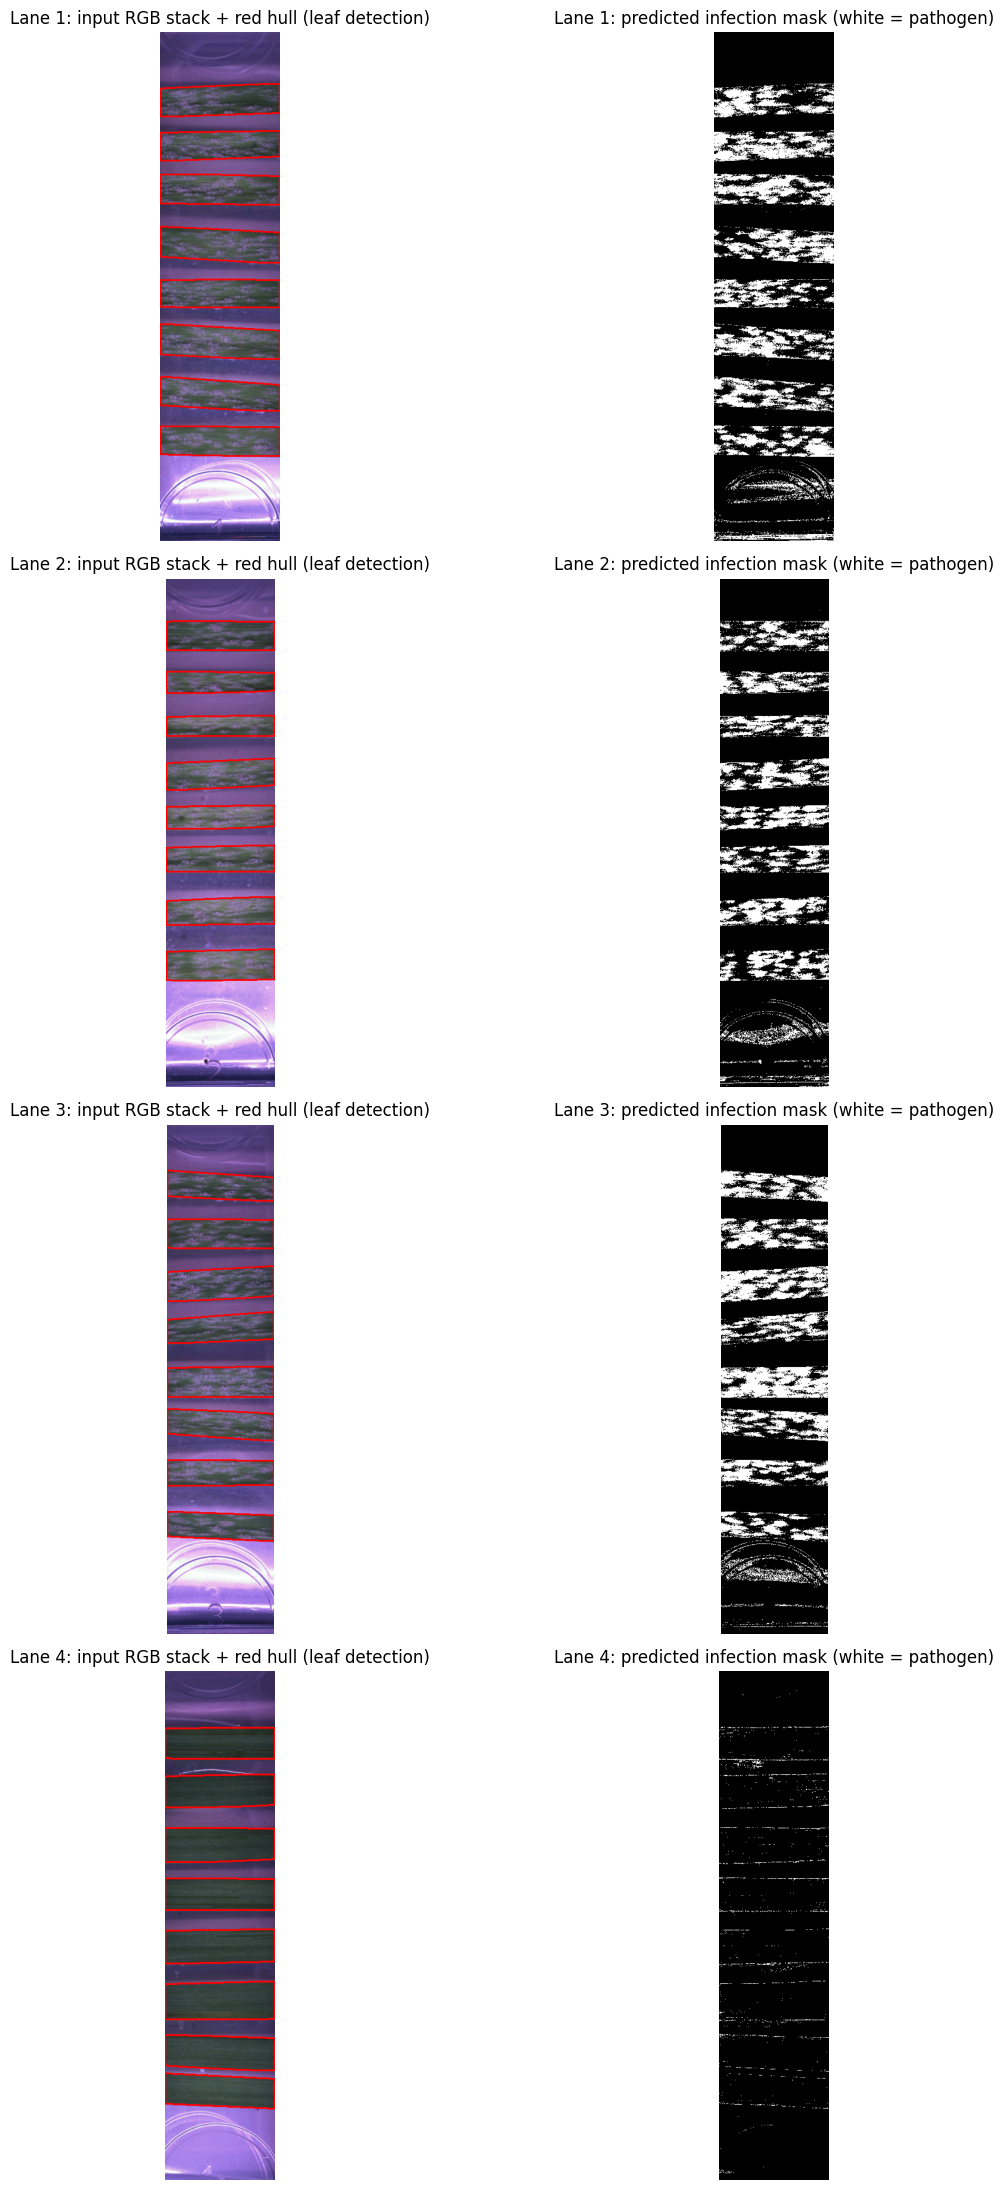

In [ ]:
import glob
import re

base_dir = os.path.join(DESTINATION_PATH, EXPERIMENT, DAI, plate_id)
leaf_predict_paths = sorted(glob.glob(os.path.join(base_dir, "*_leaf_predict.png")),
                            key=lambda p: int(re.search(r"_(\d+)_leaf_predict.png$", p).group(1)))
disease_paths = sorted(glob.glob(os.path.join(base_dir, "*_disease_predict.png")),
                       key=lambda p: int(re.search(r"_(\d+)_disease_predict.png$", p).group(1)))
assert leaf_predict_paths and disease_paths, "pipeline produced no lane images"

n = len(leaf_predict_paths)
fig, axes = plt.subplots(n, 2, figsize=(16, 5.5 * n))
for i, (lp, dp) in enumerate(zip(leaf_predict_paths, disease_paths)):
    lane_rgb = cv2.cvtColor(cv2.imread(lp), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(dp, cv2.IMREAD_GRAYSCALE)
    axes[i, 0].imshow(lane_rgb)
    axes[i, 0].set_title(f"Lane {i + 1}: input RGB stack + red hull (leaf detection)")
    axes[i, 1].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[i, 1].set_title(f"Lane {i + 1}: predicted infection mask (white = pathogen)")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 4.1 Per-leaf infection bar chart (additional visualization)

A simple per-leaf bar chart of the `%_Inf` values from the CSV above. This graph is **created for this notebook** from the actual run output (the paper reports correlations over 108 plates rather than per-leaf bars for this plate); it is not an author figure.

**日本語:** 上のCSVの感染率を葉ごとに棒グラフ化したものです（本ノートブック独自の追加可視化であり、論文の図ではありません）。

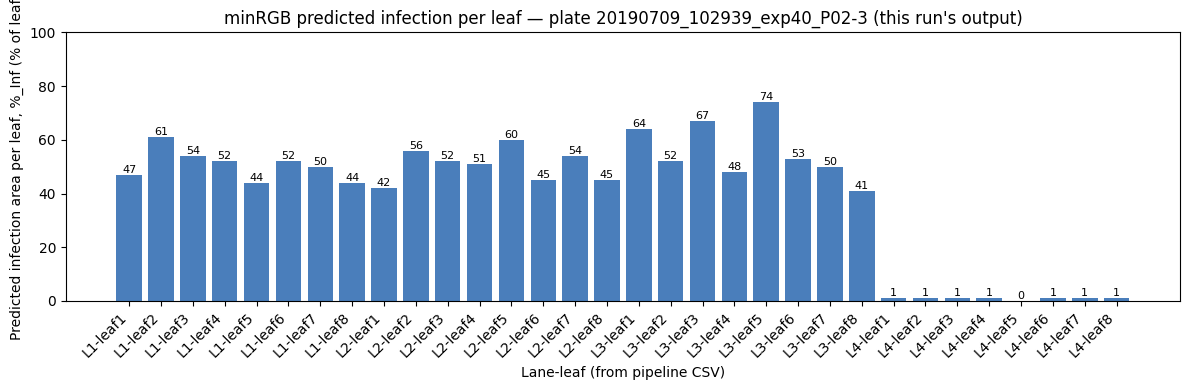

summary exported to /content/mb_results/infection_summary.csv


In [ ]:
import re

labels = [f"L{int(r.Lane_ID)}-leaf{int(r.Leaf_ID)}" for r in df.itertuples()]
values = df["%_Inf"].astype(float).tolist()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, values, color="#4a7ebb")
ax.set_ylabel("Predicted infection area per leaf, %_Inf (% of leaf)")
ax.set_xlabel("Lane-leaf (from pipeline CSV)")
ax.set_title(f"minRGB predicted infection per leaf — plate {plate_id} (this run's output)")
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt="%.0f", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

export_path = "/content/mb_results/infection_summary.csv"
df.to_csv(export_path, sep=";", index=False)
print("summary exported to", export_path)

## 5. Interpretation, scope, and validation record

**What was executed (validation record):** this notebook was run top-to-bottom on a Google Colab **CPU** runtime, re-executing every setup and download step inside the run: the pinned repository was re-cloned, the test-plate bytes were re-downloaded from e!DAL and re-verified, and previous outputs were cleared before the pipeline ran. It produced the per-leaf CSV, prediction masks, and lane images shown above. The provenance check against the authors' bundled expected CSV is reported in section 3.2.

**Scientific scope:** PARTIAL demonstration of the paper's §3.3 minRGB segmentation branch on **one plate**. One plate's output is not a reproduction of the paper's dataset-level validation (n=108 barley plates correlated with six-expert manual scores and qPCR, §3.4) nor of the Random-Forest machine-learning branch (§3.2).

**Faithful reuse vs. glue:** the scientific path (channel stacking, white balance, Otsu frame thresholding with 8×8 dilation, lane/leaf segmentation, minRGB rule thresholds 60/130 and backlight 150, `%_Inf` formula) is the authors' code at the pinned commit, unchanged. Notebook-specific glue: the download/clone cells, the `cv2.findContours` list shim (modern OpenCV returns an immutable tuple where the author's pinned OpenCV 4.2 returned a list; documented in §3), the `store_leaf_path=None` choice, display and comparison cells. The preprint-era repository (`macrobot_paper`, 404) could not be pinned; the maintained head is used and labeled accordingly.

**日本語（解釈と範囲）:** 本ノートブックは論文 §3.3 の minRGB 分岐を著者コード（ピン留したコミット）のまま1プレートで実行した **部分再現** です。結果CSV・予測マスク・レーン画像はこの実行で生成された実際の出力です。§3.2 の機械学習分岐や §3.4 の n=108 検証実験は範囲外であり、1プレートの結果は論文のデータセット全体の精度を保証しません。

**References**
- Lück et al., *"Macrobot" – an automated segmentation-based system for powdery mildew disease quantification*, bioRxiv 2020.03.16.993451v1, DOI 10.1101/2020.03.16.993451.
- Lueck et al. 2020, *BluVision Macro*, JOSS 5(51):2259, DOI 10.21105/joss.02259 (the software publication of the maintained code).
- Author code: https://github.com/snowformatics/macrobot @ `bb72fc5bfa31afd3fd8c17d5016ae9f79059a88b` (GPL-3.0).
- Test plate images: e!DAL DOI 10.5447/ipk/2020/7 (Douchkov & Lueck, IPK).
- Validation dataset (not used here, scope note): e!DAL DOI 10.5447/ipk/2020/23.